In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
#loading dataset
df = pd.read_csv("../data/raw/online_retail_II.csv", encoding='ISO-8859-1')

In [6]:
df.shape
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085.0,United Kingdom


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1048575 non-null  object 
 1   StockCode    1048575 non-null  object 
 2   Description  1044203 non-null  object 
 3   Quantity     1048575 non-null  int64  
 4   InvoiceDate  1048575 non-null  object 
 5   Price        1048575 non-null  float64
 6   Customer ID  811893 non-null   float64
 7   Country      1048575 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 64.0+ MB


In [8]:
df.describe()

,Quantity,Price,Customer ID
count,1.048575e+06,1.048575e+06,811893.000000
mean,9.957525e+00,4.627346e+00,15324.712265
std,1.335187e+02,1.228024e+02,1697.033034
min,-7.421500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13971.000000
50%,3.000000e+00,2.100000e+00,15260.000000
75%,1.000000e+01,4.150000e+00,16795.000000
max,7.421500e+04,3.897000e+04,18287.000000


In [9]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4372
Quantity            0
InvoiceDate         0
Price               0
Customer ID    236682
Country             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(34150)

In [11]:
df["Customer ID"].drop_duplicates().head()

0     13085.0
12    13078.0
31    15362.0
54    18102.0
71    12682.0
Name: Customer ID, dtype: float64

In [12]:
df[df["Price"] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,29-04-2010 13:36,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,19-07-2010 11:24,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,20-10-2010 12:04,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,12-08-2011 14:51,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,12-08-2011 14:52,-11062.06,NaN,United Kingdom


In [13]:
df[df["Quantity"] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,01-12-2009 10:33,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,01-12-2009 10:33,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,01-12-2009 10:33,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,01-12-2009 10:33,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,01-12-2009 10:33,2.95,16321.0,Australia


In [14]:
df["Customer ID"].nunique()

5924

In [15]:
df["StockCode"].nunique()

5304

In [18]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True)

In [19]:
print(df["InvoiceDate"].min())
print(df["InvoiceDate"].max())

2009-12-01 07:45:00
2011-12-04 13:15:00


In [21]:
df["Country"].value_counts().head(10)

Country
United Kingdom    963819
EIRE               17581
Germany            17327
France             14100
Netherlands         5054
Spain               3740
Switzerland         3189
Belgium             3056
Portugal            2566
Australia           1913
Name: count, dtype: int64

In [22]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

In [23]:
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

In [24]:
df["TotalPrice"] = df["Quantity"] * df["Price"]

In [25]:
df["TotalPrice"].describe()

count    1.048575e+06
mean     1.809360e+01
std      1.798897e+02
min     -7.718360e+04
25%      3.750000e+00
50%      9.900000e+00
75%      1.770000e+01
max      7.718360e+04
Name: TotalPrice, dtype: float64

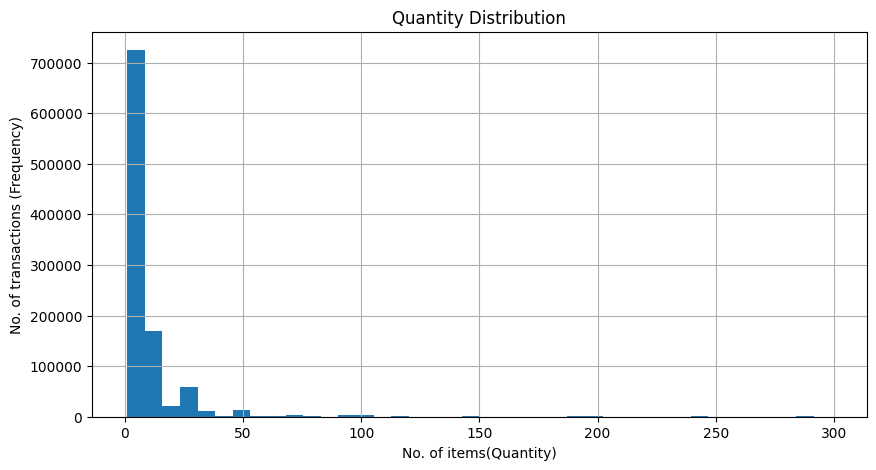

In [26]:
plt.figure(figsize=(10,5))
df[(df["Quantity"] > 0) & (df["Quantity"] < 300)]["Quantity"].hist(bins=40)
plt.title("Quantity Distribution")
plt.xlabel("No. of items(Quantity)")
plt.ylabel("No. of transactions (Frequency)")
plt.show()

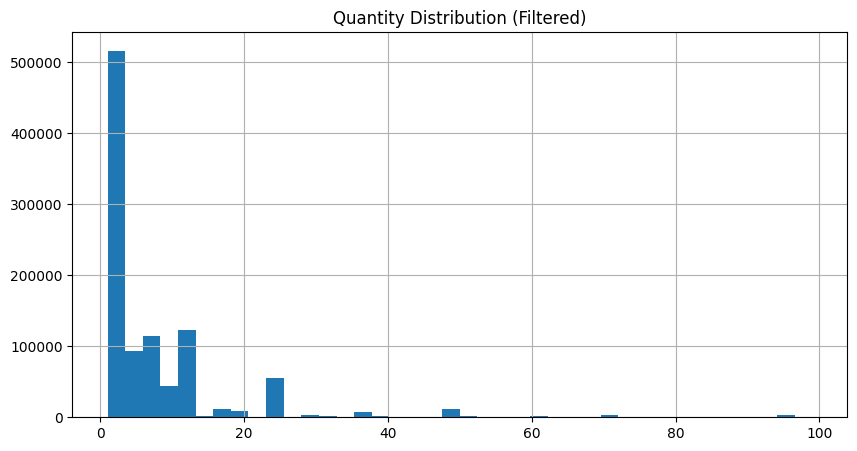

In [27]:
plt.figure(figsize=(10,5))
df[(df["Quantity"] > 0) & (df["Quantity"] < 100)]["Quantity"].hist(bins=40)
plt.title("Quantity Distribution (Filtered)")
plt.show()

In [28]:
df["Description"].value_counts().head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    5875
REGENCY CAKESTAND 3 TIER              4364
JUMBO BAG RED RETROSPOT               3426
ASSORTED COLOUR BIRD ORNAMENT         2928
PARTY BUNTING                         2746
STRAWBERRY CERAMIC TRINKET BOX        2613
LUNCH BAG  BLACK SKULL.               2497
JUMBO STORAGE BAG SUKI                2406
HEART OF WICKER SMALL                 2295
JUMBO SHOPPER VINTAGE RED PAISLEY     2267
Name: count, dtype: int64